# Machine Learning for Public Infrastructure Reliability: Predicting Water Well Status in Tanzania
### *Introduction*
Tanzania faces significant challenges in providing reliable clean water access to its population. Although many water wells have been installed, some are non-functional or require repair.
Access to clean and functional water sources is essential for communities.
This project aims to predict the condition of water wells (functional, needs repair, or non-functional) using available data.

#### *Objective*
The goal is to build machine learning models that can accurately classify the condition of a water well, helping organizations prioritize maintenance and resource allocation.

### Data Understanding
The dataset contains information about water wells, including:

- Funding details
- Geographic location
- Population served
- Construction year
- Technical and operational attributes

Keeping in mind each record represents a single water well. Let's get into it!

In [1]:
#import python libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


This libraries are used for data manipulation, visualization, preprocessing and machine learning modelling.

## Loading Datasets for Use

In [2]:
#load the dataset
values = pd.read_csv("Data/Raw/Training_Set_Values.csv")
labels = pd.read_csv("Data/Raw/Training_Set_Labels.csv")

values.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [3]:
labels.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


## Merging Operations for the Datasets
The dataset is separated into two files:
- Feature data(pump characteristics)
- Target Labels (pump status)

In [4]:
#merge the values and labels dataframes on the 'id' column
df =values.merge(labels, on='id')
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
#check shape of the dataframe
df.shape

(59400, 41)

In [6]:
#inspect the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55765 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59400 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [7]:
#inspect the dataset
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


### *Data Cleaning*
To improve data quality, the following steps are performed:

- Remove duplicate records
- Identify and handle missing values
- Prepare features for modeling
- Clean data ensures better model performance and reliability.

In [8]:
#Drop duplicates and Missing Values Hndling
df = df.drop_duplicates()
df.isnull().sum()

id                           0
amount_tsh                   0
date_recorded                0
funder                    3635
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     0
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3877
scheme_name              28166
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

### *Defining Features and Target*

- *Target Variable*

The target variable is status_group, which represents the condition of the water well.

- *Feature Variables*

All other variables are treated as input features, including:

- Funding amount
- Geographic data
- Population served
- Construction details

Some features contain zero values representing missing data.Feature scales vary significantly (e.g., population vs. funding. Categorical and numerical features must be handled differently
These factors will be addressed using preprocessing pipelines.


In [9]:
#Target variable
y = df['status_group']

In [10]:
#Investigate the target variable
df["status_group"].value_counts(normalize=True)

functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: status_group, dtype: float64

In [11]:
# Features
X = df.drop('status_group', axis=1)

### *Train Test Split*
We split the data to investigate the following:

- Training set → used to train the model

- Testing set → used to evaluate performance

This ensures the model can generalize to unseen data.

In [12]:
#Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42
 )

### *Data Preprocessing (Pipelines)*
Pipelines help automate and standardize preprocessing by:

- Handling missing values
- Scaling numerical features
- Encoding categorical variables

Ensuring Consistency and Preventing Data Leakage using the following steps:

- Numerical features → imputed and scaled
-Categorical features → imputed and one-hot encoded

In [13]:
# Automatically detect column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### *Re-Usable Evaluation Function*
A re-usable function improves consistency and efficiency across models. This is achieved by;
- Training Models
- Performance Evaluation
- Result Visualization

Model performance is assesed by Accuracy(Gneral correctness of the Model), Confusion Matrix(Detailed Prediction Breakdown) and Classification Reports(Precision, Recall,F1 Score)

In [14]:
# Evaluation of all Models using one function
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Check if X_train has features
    if X_train.shape[1] == 0:
        raise ValueError("X_train has 0 features! Check your preprocessing/feature selection.")
    
    # Define the Pipeline
    pipeline = Pipeline (steps=[
        ('preprocessor', preprocessor),  # preprocessor must have proper numeric/categorical columns
        ('model', model)])
    
    #Fit Pipeline
    X_transformed = preprocessor.fit_transform(X_train)
    print(f"Shape of X_train after preprocessing: {X_transformed.shape}")

 # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    # Classification report
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc

### *BASELINE MODEL*

 ***Logistic Regression***

We start with a simple model to establish a baseline.This helps us understand:

- How well a basic model performs

- Whether more complex models are necessary

Shape of X_train after preprocessing: (47520, 56871)


c:\Users\HP\anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Accuracy: 0.7924
                         precision    recall  f1-score   support

             functional       0.79      0.88      0.83      6457
functional needs repair       0.56      0.31      0.40       851
         non functional       0.82      0.76      0.79      4572

               accuracy                           0.79     11880
              macro avg       0.72      0.65      0.67     11880
           weighted avg       0.79      0.79      0.78     11880



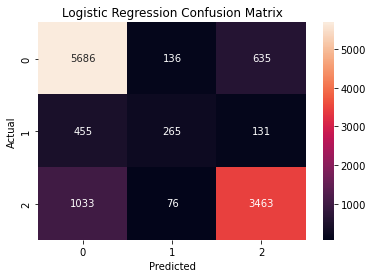

In [15]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_acc = evaluate_model(
    "Logistic Regression",
    baseline_model,
     X_train, X_test, y_train, y_test
 )


### *ADVANCED MODEL*
We'll use Random Forest because  it is:

 ***A more powerful model that***
- Handles complex relationships
- Reduces overfitting through multiple decision trees
- This model is expected to outperform the baseline.


Shape of X_train after preprocessing: (47520, 56871)

Random Forest Accuracy: 0.8135
                         precision    recall  f1-score   support

             functional       0.81      0.90      0.85      6457
functional needs repair       0.60      0.35      0.44       851
         non functional       0.85      0.78      0.81      4572

               accuracy                           0.81     11880
              macro avg       0.75      0.67      0.70     11880
           weighted avg       0.81      0.81      0.81     11880



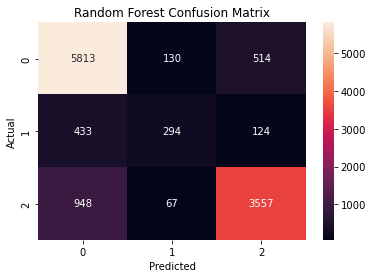

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_acc = evaluate_model(
   "Random Forest",
   rf_model,
   X_train, X_test, y_train, y_test
)

### *ENSEMBLE MODEL*
Voting Classifier

To further improve performance, we combine multiple models:

- Logistic Regression
- Random Forest
- Gradient Boosting

This approach leverages the strengths of each model for the purpose of making one single prediction hence improving accuracy.

Shape of X_train after preprocessing: (47520, 56871)


c:\Users\HP\anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Ensemble Model Accuracy: 0.8090
                         precision    recall  f1-score   support

             functional       0.79      0.92      0.85      6457
functional needs repair       0.68      0.26      0.38       851
         non functional       0.86      0.75      0.80      4572

               accuracy                           0.81     11880
              macro avg       0.78      0.64      0.68     11880
           weighted avg       0.81      0.81      0.80     11880



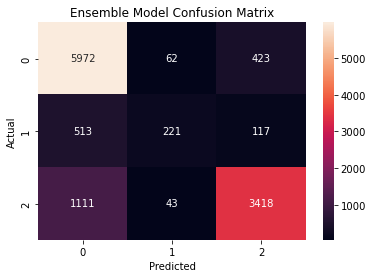

In [17]:
# Combines multiple models

ensemble_model = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('gb', GradientBoostingClassifier())
], voting='soft')

ensemble_acc = evaluate_model(
    "Ensemble Model",
    ensemble_model,
    X_train, X_test, y_train, y_test
)

### ***Ensemble Model Performance Summary***

The ensemble model achieved an overall accuracy of 81%, outperforming the baseline Logistic Regression model. This indicates that combining multiple models improved predictive performance and model stability.

Key Insights for Take away

- Strong performance on majority classes

- The model performs very well in predicting:

- Functional wells (recall: 0.92)

- Non-functional wells (precision: 0.86, recall: 0.75)

This suggests the model is highly effective at identifying wells that are clearly working or not working.

***Improved overall accuracy***

The ensemble approach (Voting Classifier) leverages the strengths of individual models, leading to better generalization and higher accuracy compared to single models.

Weak performance on minority class

The class “functional needs repair” has:

- Low recall (0.26) → many such wells are not correctly identified

This indicates class imbalance and difficulty distinguishing borderline cases.

- Balanced but slightly skewed performance

The weighted average (0.81) aligns with overall accuracy, showing good performance on dominant classes.

However, the macro average (~0.68 F1-score) highlights uneven performance across classes.

## *MODEL COMPARISON*
This is a performance comparison, based on accuracy and other metrics.

This helps identify the best-performing model for the problem.

In [18]:
# Compare all models

results = {
     'Logistic Regression': baseline_acc,
    'Random Forest': rf_acc,
    'Ensemble': ensemble_acc
}

print("\nModel Comparison:")
for model, score in results.items():
     print(f"{model}: {score:.4f}")


Model Comparison:
Logistic Regression: 0.7924
Random Forest: 0.8135
Ensemble: 0.8090


In [19]:
#Download cleaned Data
df.to_csv("clean_water_wells.csv", index=False)

### ***FINAL RECOMMENDATION***
Based on our evaluation findings,we find that Ensemble model provides the best performance

### ***Business Recommendations***
- Use the best-performing model to predict well conditions
- Prioritize repairs for wells predicted as non-functional as the older wells have declining water quantity.
- Improve data collection to reduce missing values



### ***Conclusion***

This project successfully developed a machine learning model to predict the operational status of water wells in Tanzania.

The Ensemble model achieved strong predictive performance and identified key factors influencing well functionality, including geographic location, water availability, and infrastructure characteristics.
It outperform individual models by leveraging their collective strengths.(Logistic Regression and Random Forest)

### ***Future Work***
- Hyperparameter tuning
- Geospatial modeling
- Handling class imbalance further